Packages and Modules Management

In [1]:
# installing required modules
!pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn tensorflow shap scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.5 MB/s eta 0:00:00


In [2]:
# importing required libraries
import pandas as pd
import numpy as np

# importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# importing preprocessing tools
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from skopt import BayesSearchCV

# importing ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# importing evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve

# importing deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding

# importing NLP tools
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# importing dataset
from ucimlrepo import fetch_ucirepo

# importing shap
import shap

# importing joblib for saving models
import joblib

# suppressing warnings
import warnings
warnings.filterwarnings('ignore')

Data Gathering

In [4]:
# fetch dataset
phiusiil_phishing_url_website = fetch_ucirepo(id=967)

In [5]:
# import data as pandas dataframes
X = phiusiil_phishing_url_website.data.features
y = phiusiil_phishing_url_website.data.targets

Exploratory Data Analysis

In [6]:
# metadata
display(phiusiil_phishing_url_website.metadata)

{'uci_id': 967,
 'name': 'PhiUSIIL Phishing URL (Website)',
 'repository_url': 'https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/967/data.csv',
 'abstract': 'PhiUSIIL Phishing URL Dataset is a substantial dataset comprising 134,850 legitimate and 100,945 phishing URLs. Most of the URLs we analyzed, while constructing the dataset, are the latest URLs. Features are extracted from the source code of the webpage and URL. Features such as CharContinuationRate, URLTitleMatchScore, URLCharProb, and TLDLegitimateProb are derived from existing features.',
 'area': 'Computer Science',
 'tasks': ['Classification'],
 'characteristics': ['Tabular'],
 'num_instances': 235795,
 'num_features': 54,
 'feature_types': ['Real', 'Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['label'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2024,
 'last_updat

In [7]:
# variable information
display(phiusiil_phishing_url_website.variables)

,name,role,type,demographic,description,units,missing_values
0,FILENAME,Other,Categorical,None,None,None,no
1,URL,Feature,Categorical,None,None,None,no
2,URLLength,Feature,Integer,None,None,None,no
3,Domain,Feature,Categorical,None,None,None,no
4,DomainLength,Feature,Integer,None,None,None,no
5,IsDomainIP,Feature,Integer,None,None,None,no
6,TLD,Feature,Categorical,None,None,None,no
7,URLSimilarityIndex,Feature,Integer,None,None,None,no
8,CharContinuationRate,Feature,Integer,None,None,None,no
9,TLDLegitimateProb,Feature,Continuous,None,None,None,no


In [8]:
# Create dataframe by combining X and y
data = pd.concat([X, y], axis=1)

In [9]:
# Display the columns of the dataset
display(data.columns)

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

In [10]:
# Display the shape of the dataset
display(data.shape)

(235795, 55)

In [11]:
# Display the first few rows of the dataset
display(data.head())

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [12]:
# Check for the missing values
data.isnull().sum().sum()

np.int64(0)

In [13]:
# Checking dataset info
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

None

In [14]:
# dropping unnecessary columns
data = data.drop(columns=['id'], errors='ignore')

Data Visualisation

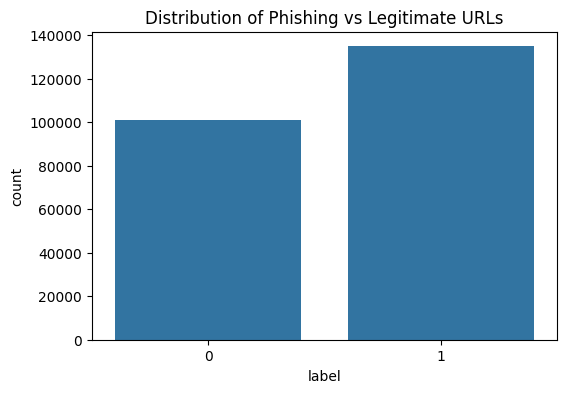

In [15]:
# Class distribution visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data)
plt.title('Distribution of Phishing vs Legitimate URLs')
plt.show()

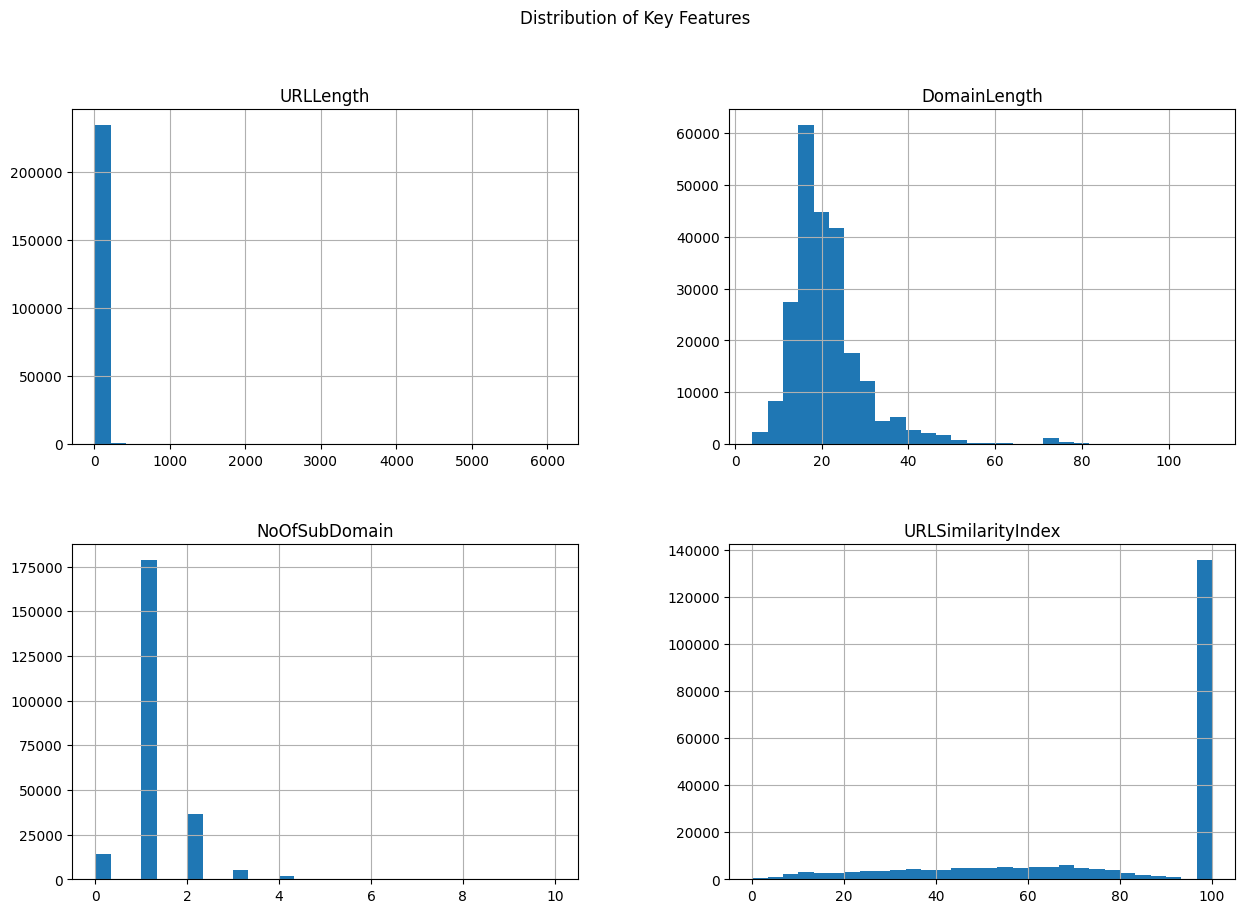

In [16]:
# Visualizing distributions of key numerical features
features_to_plot = ['URLLength', 'DomainLength', 'NoOfSubDomain', 'URLSimilarityIndex']
data[features_to_plot].hist(bins=30, figsize=(15, 10))
plt.suptitle('Distribution of Key Features')
plt.show()

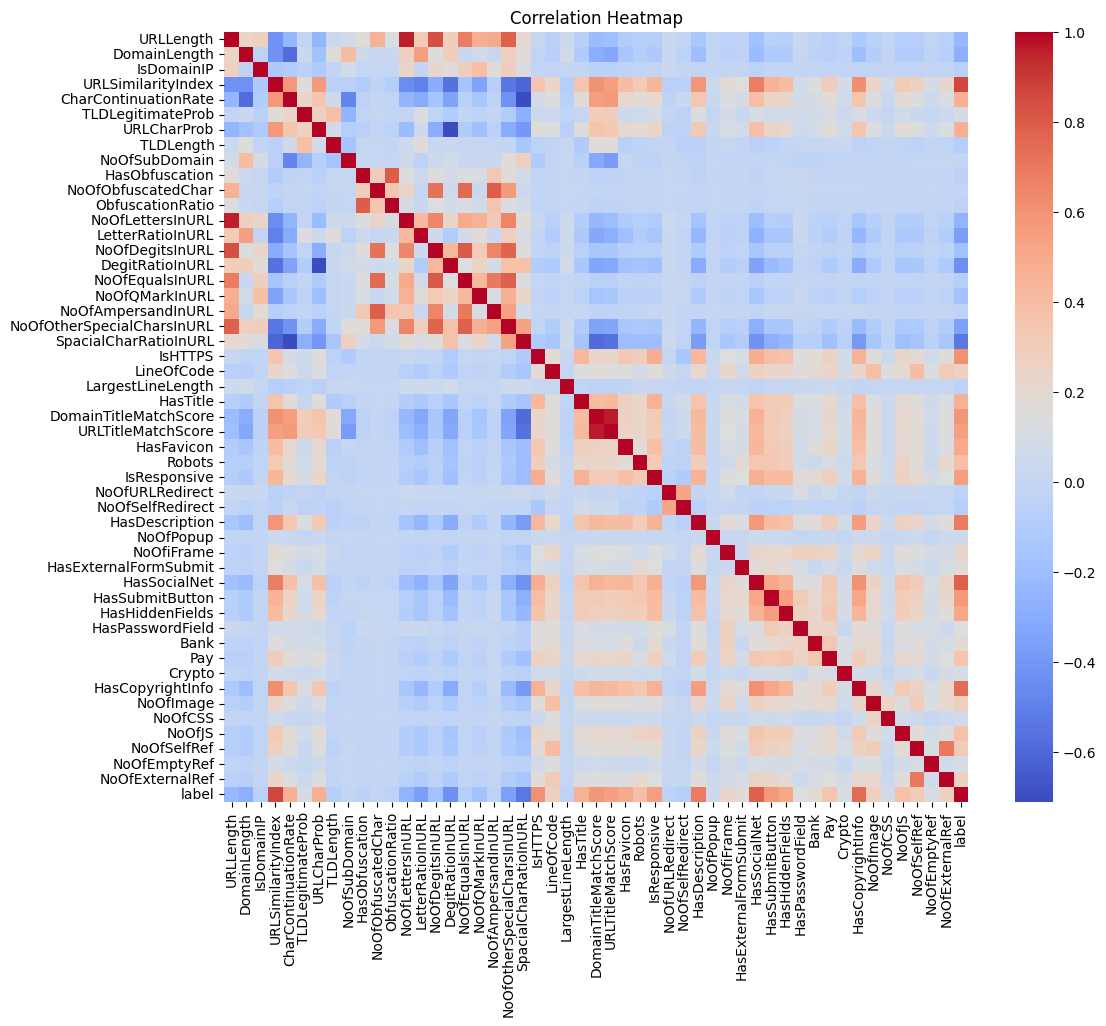

In [17]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 10))
numeric_data = data.select_dtypes(include=[np.number])
corr = numeric_data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

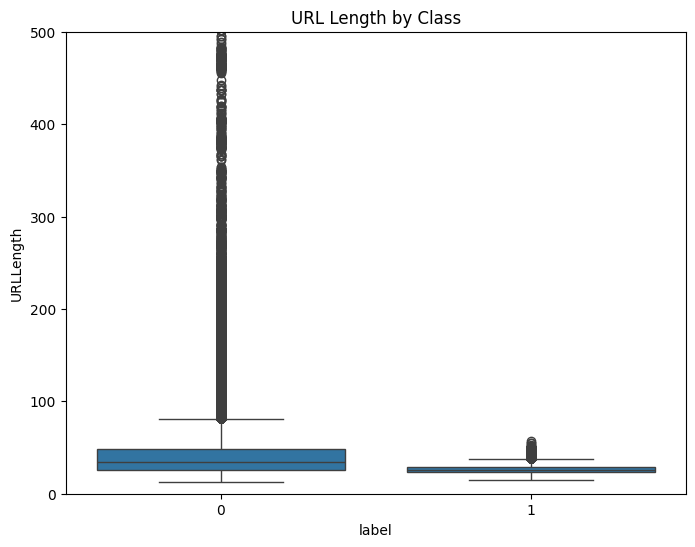

In [18]:
# Boxplot for URL Length by Label
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='URLLength', data=data)
plt.title('URL Length by Class')
plt.ylim(0, 500)
plt.show()

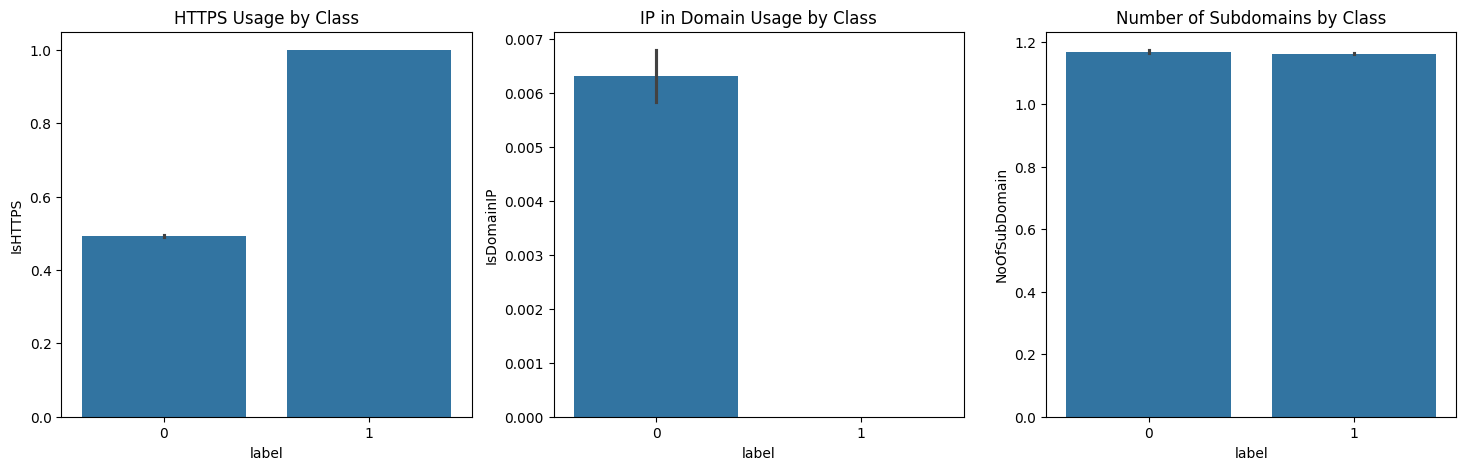

In [19]:
# Comparison of security features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='label', y='IsHTTPS', data=data, ax=axes[0])
axes[0].set_title('HTTPS Usage by Class')
sns.barplot(x='label', y='IsDomainIP', data=data, ax=axes[1])
axes[1].set_title('IP in Domain Usage by Class')
sns.barplot(x='label', y='NoOfSubDomain', data=data, ax=axes[2])
axes[2].set_title('Number of Subdomains by Class')
plt.show()

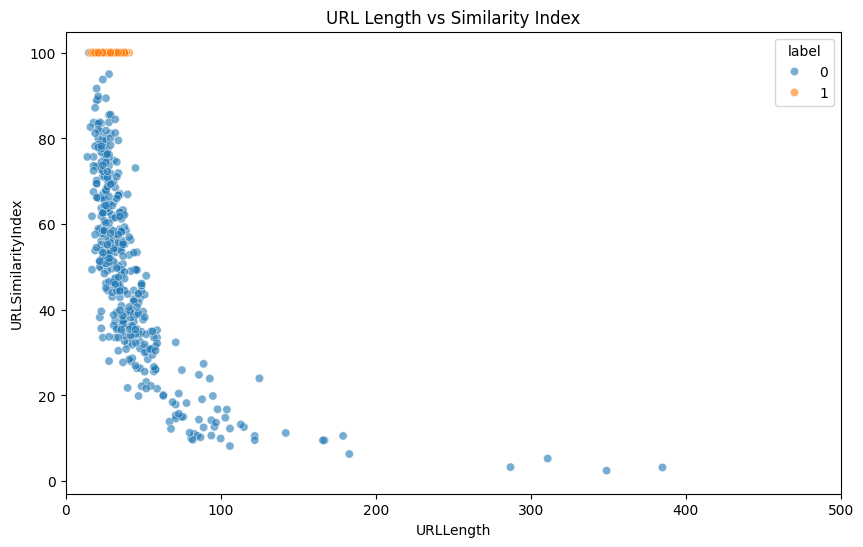

In [20]:
# Scatter plot for URL Length vs URL Similarity Index
plt.figure(figsize=(10, 6))
sns.scatterplot(x='URLLength', y='URLSimilarityIndex', hue='label', data=data.sample(1000, random_state=42), alpha=0.6)
plt.title('URL Length vs Similarity Index')
plt.xlim(0, 500)
plt.show()

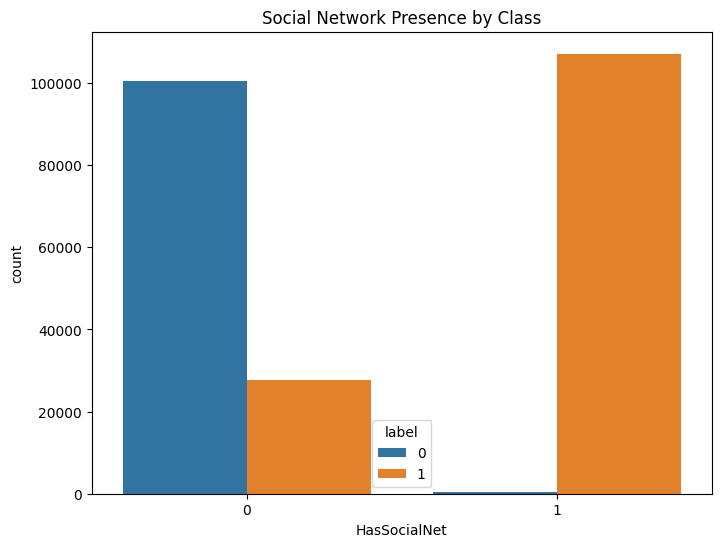

In [21]:
# Distribution of Social Network presence
plt.figure(figsize=(8, 6))
sns.countplot(x='HasSocialNet', hue='label', data=data)
plt.title('Social Network Presence by Class')
plt.show()

Data Preprocessing

In [22]:
# defining function for entropy calculation
def calculate_entropy(url):
    # calculating probability of each character
    prob = [float(url.count(c)) / len(url) for c in dict.fromkeys(list(url))]
    # calculating entropy
    entropy = -sum([p * np.log2(p) for p in prob])
    return entropy

In [23]:
# applying entropy feature
data['entropy'] = data['URL'].apply(calculate_entropy)

In [24]:
# creating URL length feature
data['url_length'] = data['URL'].apply(len)

In [25]:
# counting special characters
data['special_char_count'] = data['URL'].apply(lambda x: sum([1 for c in x if not c.isalnum()]))

In [26]:
# keyword detection feature
keywords = ['login', 'secure', 'verify', 'bank']
data['keyword_flag'] = data['URL'].apply(
    lambda x: int(any(k in x.lower() for k in keywords)))

In [27]:
#  Dropping non-numeric string columns for modeling
X_model = data.drop(columns=['label', 'URL', 'Domain', 'TLD', 'Title', 'id'], errors='ignore')
y_model = data['label']

In [28]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

In [29]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_model, test_size=0.2, random_state=42)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (188636, 54)
Testing set shape: (47159, 54)


Modelling

In [30]:
# defining models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

In [31]:
# training and evaluating models
for name, model in models.items():

    # training model
    model.fit(X_train, y_train)

    # predicting
    y_pred = model.predict(X_test)

    # calculating ROC-AUC
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 0.9999999834574739

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 1.0

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00   

Cross Validation

In [32]:
# performing cross validation
rf = RandomForestClassifier()

scores = cross_val_score(rf, X_scaled, y_model, cv=5)

In [33]:
# printing results
print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [0.9999788 1.        0.9999788 1.        1.       ]
Mean Accuracy: 0.9999915180559384


LSTM model

In [34]:
# extracting URL column
urls = data['URL'].astype(str)

In [35]:
# initialising tokenizer
tokenizer = Tokenizer(char_level=True)

In [36]:
# fitting tokenizer
tokenizer.fit_on_texts(urls)

In [37]:
# converting URLs into sequences
sequences = tokenizer.texts_to_sequences(urls)

In [38]:
# padding sequences
X_seq = pad_sequences(sequences, maxlen=100)

In [39]:
# defining target
y_seq = data['label']

In [40]:
# splitting dataset
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42)

In [41]:
# defining LSTM model
lstm_model = Sequential()

In [42]:
# adding embedding layer
lstm_model.add(Embedding(len(tokenizer.word_index)+1, 32, input_length=100))

In [43]:
# adding LSTM layer
lstm_model.add(LSTM(64))

In [44]:
# output layer
lstm_model.add(Dense(1, activation='sigmoid'))

In [45]:
# compiling model
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [46]:
# training model
lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32)

Epoch 1/5
5895/5895 ━━━━━━━━━━━━━━━━━━━━ 171s 29ms/step - accuracy: 0.9738 - loss: 0.0758
Epoch 2/5
5895/5895 ━━━━━━━━━━━━━━━━━━━━ 204s 29ms/step - accuracy: 0.9823 - loss: 0.0524
Epoch 3/5
5895/5895 ━━━━━━━━━━━━━━━━━━━━ 200s 29ms/step - accuracy: 0.9978 - loss: 0.0129
Epoch 4/5
5895/5895 ━━━━━━━━━━━━━━━━━━━━ 203s 29ms/step - accuracy: 0.9980 - loss: 0.0119
Epoch 5/5
5895/5895 ━━━━━━━━━━━━━━━━━━━━ 171s 29ms/step - accuracy: 0.9981 - loss: 0.0116


In [47]:
# evaluating model
loss, acc = lstm_model.evaluate(X_test_seq, y_test_seq)

print("LSTM Accuracy:", acc)

1474/1474 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9981 - loss: 0.0115
LSTM Accuracy: 0.9980703592300415


Hyperparameter Tuning

In [48]:
# defining parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]}

In [49]:
# initialising model with grid search
rf = RandomForestClassifier()
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

In [50]:
# training model
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [51]:
# getting best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [52]:
# Storing best model
best_rf = grid.best_estimator_

ROC Curve

In [53]:
# predicting probabilities
y_prob = best_rf.predict_proba(X_test)[:,1]

In [54]:
# calculating ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

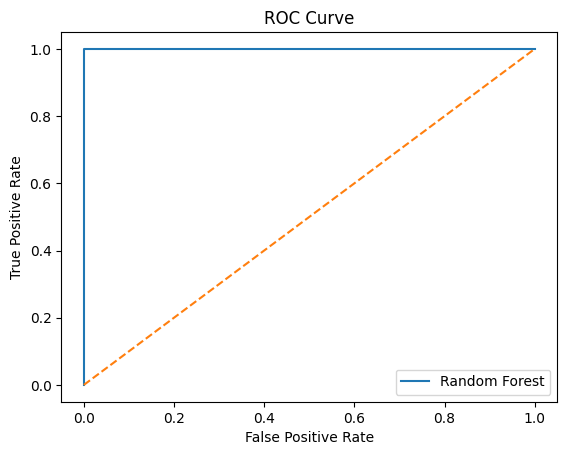

In [55]:
# plotting ROC curve
plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Precision Recall Curve

In [56]:
# calculating precision-recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

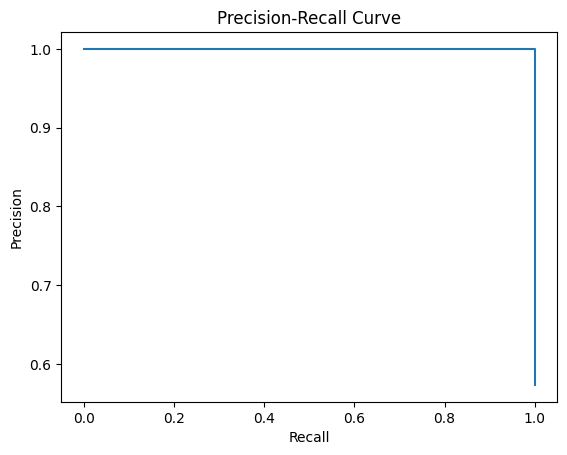

In [57]:
# plotting curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Shap Explanation

In [58]:
# creating explainer
explainer = shap.TreeExplainer(best_rf)

In [59]:
# calculating shap values
shap_values = explainer.shap_values(X_test)

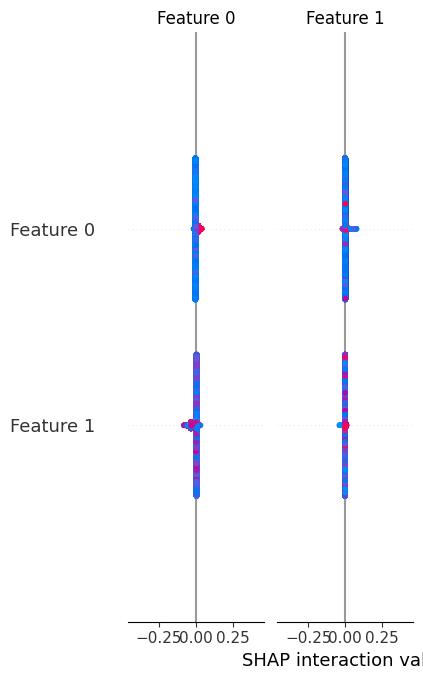

In [60]:
# plotting feature importance
shap.summary_plot(shap_values, X_test)

Confusion Matrix Visualisation

In [61]:
# predicting using best model
y_pred = best_rf.predict(X_test)

In [62]:
# creating confusion matrix
cm = confusion_matrix(y_test, y_pred)

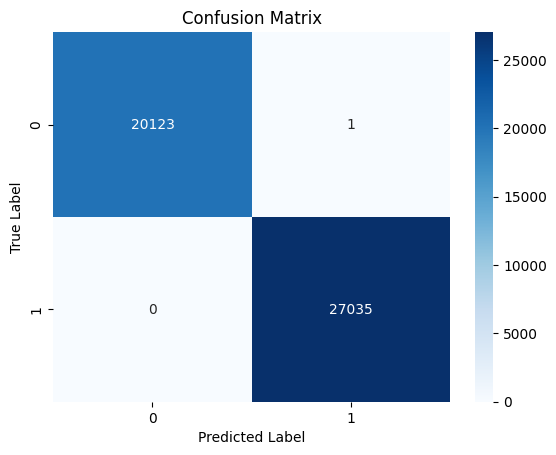

In [63]:
# plotting confusion matrix
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Bayesian Optimisation

In [64]:
# defining search space
param_space = {
    'n_estimators': (100, 300),
    'max_depth': (5, 30),
    'min_samples_split': (2, 10)}

In [65]:
# initializing Bayesian optimization
bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=param_space,
    n_iter=20,
    cv=3,
    n_jobs=-1)

In [66]:
# training
bayes_search.fit(X_train, y_train)

BayesSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=20, n_jobs=-1,
              search_spaces={'max_depth': (5, 30), 'min_samples_split': (2, 10),
                             'n_estimators': (100, 300)})

In [67]:
# best parameters
print("Best Parameters of Bayesian:", bayes_search.best_params_)

Best Parameters of Bayesian: OrderedDict({'max_depth': 28, 'min_samples_split': 4, 'n_estimators': 206})


In [68]:
# extracting best model from Bayesian optimization
best_bayes_rf = bayes_search.best_estimator_

In [69]:
# predicting using Bayesian optimized model
y_pred_bayes = best_bayes_rf.predict(X_test)

In [70]:
# probability prediction
y_prob_bayes = best_bayes_rf.predict_proba(X_test)[:,1]

In [71]:
# evaluation of Bayesian Optimized Model Results
print(classification_report(y_test, y_pred_bayes))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bayes))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

ROC-AUC: 1.0


Grid Search and Bayesian Comparison

In [72]:
print("Grid Search ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))
print("Bayesian ROC-AUC:", roc_auc_score(y_test, y_prob_bayes))

Grid Search ROC-AUC: 1.0
Bayesian ROC-AUC: 1.0


Actual VS Predicted Data

In [73]:
# predicting values
y_pred = best_rf.predict(X_test)

In [74]:
# predicting probabilities
y_prob = best_rf.predict_proba(X_test)[:,1]

In [75]:
# creating dataframe
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

In [76]:
# displaying first 20 rows
print(comparison_df.head(20))

    Actual  Predicted  Probability
0        1          1       1.0000
1        0          0       0.0000
2        0          0       0.0000
3        0          0       0.0000
4        1          1       1.0000
5        1          1       1.0000
6        0          0       0.0025
7        0          0       0.0000
8        0          0       0.0000
9        0          0       0.0000
10       1          1       1.0000
11       1          1       1.0000
12       0          0       0.0000
13       0          0       0.0000
14       0          0       0.0000
15       0          0       0.0000
16       1          1       1.0000
17       0          0       0.0000
18       1          1       1.0000
19       1          1       1.0000


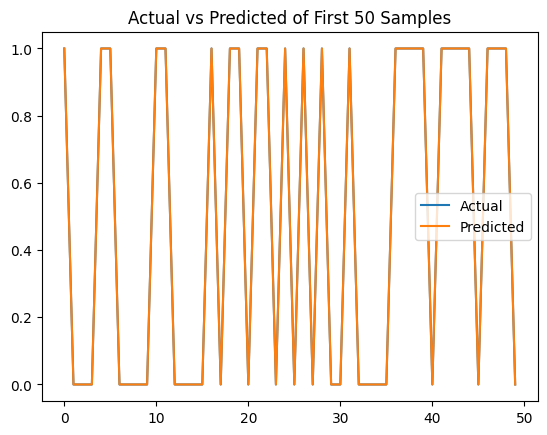

In [77]:
# plotting first 50 predictions
plt.figure()
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted of First 50 Samples")
plt.show()

Misclassified Predictions

In [78]:
# finding wrong predictions
misclassified = comparison_df[comparison_df['Actual'] != comparison_df['Predicted']]

In [79]:
# displaying some misclassified Examples
display(misclassified.head(10))

,Actual,Predicted,Probability
13772,0,1,0.53


Saving models

In [80]:
# Saving scikit-learn models
for name, model in models.items():
    joblib.dump(model, f'{name.replace(" ", "_").lower()}_model.pkl')
    print(f'Saved {name} model as {name.replace(" ", "_").lower()}_model.pkl')

Saved Logistic Regression model as logistic_regression_model.pkl
Saved Decision Tree model as decision_tree_model.pkl
Saved Random Forest model as random_forest_model.pkl
Saved Gradient Boosting model as gradient_boosting_model.pkl
Saved SVM model as svm_model.pkl


In [81]:
# Saving the best Random Forest model from Grid Search
joblib.dump(best_rf, 'best_random_forest_grid_search_model.pkl')

# Saving the best Random Forest model from Bayesian Optimization
joblib.dump(best_bayes_rf, 'best_random_forest_bayesian_optimisation_model.pkl')

# Saving the LSTM model (Keras model)
lstm_model.save('lstm_model.keras')

In [82]:
# Saving the scaler
joblib.dump(scaler, 'scaler.pkl')

# Saving the tokenizer
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']